# Ising formulations of many NP problems
<a id="ref-lucas"></a>
[Lucas 2014] Lucas, A. *Ising formulations of many NP problems*. 
Frontiers in Physics, 2 (2014). [arXiv:1302.5843](https://arxiv.org/abs/1302.5843)

# Imports



In [51]:
import numpy as np
import scipy
import math
import random

from itertools import product # for generating all possible states of x


import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation # makes the animarion
from matplotlib.animation import PillowWriter #.gif writer

from IPython.display import HTML,display # display in nb

import networkx as nx # graphs

from numba import njit #optimization


# Spin glass annealing
Importing the code _spinglass.ipynb_ from 

In [235]:
def energy(s, J, h):
    # s is a flat 1D array of spins
    # J is (n, n) matrix
    # h is (n) vector
    return 0.5 * s @ J @ s - h @ s

@njit
def sweep_once(s, J, h, T, E):
    n=len(s)
    for _ in range(n):
        i = np.random.randint(n)
        
        dE = 2 * s[i] * (J[i] @s + h[i])        

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[i] *= -1
            E += dE

    return E

def sim_annealing(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy()


# Partitioning Problems
These partitioning problems are based off _spinglass.ipynb_  where we have a spin glass model.

$H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

 We will need to swap the general ising model build function `make_2d_ising(N,J_scalar,h_scalar)` to a function that has our problems ising structure. Building Q based off the energy cost function is our goal here.

## Number Partitioning 
Given a set of $N$ positive numbers $S=\{n_1,\cdots ,n_N\}$, is there a partition of numbers into two disjoint sets such that $R$ and $S-R$ have equal sums of their elements?

Our cost function will be,

$H=-A\left(\sum_i^Nn_is_i\right)^2=$

$\underbrace{-A\sum_{i=j}^Nn_i^2}_\text{constant}-2A\sum_{i<j}^Nn_in_js_is_j$

we can drop the constant in our optimization.

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

$J_{ij}=-An_in_j$

$h_i=0$

In [ ]:
def make_partition_ising_slower(n,A=1.0):
    n = np.asarray(n, dtype=np.float64)
    N=len(n)
    J = np.zeros((N,N))
    
    for i in range(N):
        for j in range(i+1,N):
            J[i,j] = -A * n[i] * n[j]
            J[j,i] = J[i,j]
    
    h = np.zeros(N)
    
    return J, h
    
def make_partition_ising(n, A=1.0):
    n = np.asarray(n, dtype=np.float64)

    J = -2 * A * np.outer(n, n)
    np.fill_diagonal(J, 0.0)

    h = np.zeros(len(n))

    return J, h

This structure defines ouf Q interaction matrix.

In [ ]:
numbers = np.array([3,1,1,2,2,1])

J, h = make_partition_ising(numbers)

temps, energies, spins = sim_annealing(
    J, h,
    T_start=10,
    T_end=0.01,
    alpha=0.99,
    sweeps_per_T=100
)

setA = numbers[spins == 1]
setB = numbers[spins == -1]

print("Set A:", setA, "sum =", np.sum(setA))
print("Set B:", setB, "sum =", np.sum(setB))
print("Difference =", abs(np.sum(setA) - np.sum(setB)))

Defining a function for this problem

In [ ]:
def run_partition_example(numbers,sweeps):
    print("Inputed numbers:", numbers)

    J, h = make_partition_ising(numbers)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    setA = numbers[spins == 1]
    setB = numbers[spins == -1]

    print("Set A:", setA, "sum =", np.sum(setA))
    print("Set B:", setB, "sum =", np.sum(setB))
    print("Difference =", abs(np.sum(setA) - np.sum(setB)))

We can try it for a random $n_i=rand$ for $S=\{n_1,\cdots ,n_N\}$

In [7]:
for _ in range(5):
    random_numbers = np.random.randint(1, 100, size=20)
    print(run_partition_example(random_numbers, 1000))

Set A: [93 82 81 84 10 11 32 83 90] sum = 566
Set B: [96 66 48 36 41 50 24 19 65 90 22] sum = 557
Difference = 9
None
Inputed numbers: [66 68 47 13 97 51 90 48 39 25 50 42 27 41 84 14 60 47 85 58]
Set A: [66 68 47 90 25 42 27 14 60 85] sum = 524
Set B: [13 97 51 48 39 50 41 84 47 58] sum = 528
Difference = 4
None


It solves our problem to the best of its ability, minimising the distance between two sets.

## Graph Partitioning

Given some undirected graph $G(V,E)$, where $v\in v$ are vertices and $e\in E$ are edges, we take a graph with and even number of edges $N=|V|$. The optimisation problem, what is the partition of V into two subsets that minimises the number of edges connecting the two subsets?

$ H=H_A+H_B$

$=A\left(\sum_i^Ns_i\right)^2+B\sum_{(i,j)\in E}\frac{1-s_is_j}{2}$

$=\underbrace{AN} _{\text{constant}}+\underbrace{\frac{B|E|}{2}}_{\text{constant}}+2A\sum_{i>j}^ Ns_is_j -\frac{B}{2}\sum_{(i,j)\in E}  s_is_j$

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$. 

$J_{ij}=\begin{cases}
        -2A ~~~~~~~~~\text{if }~(i,j)\notin E\\
        -2A -\frac{B}{2}~~~\text{if }~(i,j)\in E
    \end{cases}$

$h_i=0$

There exists a constraint on $A$ and $B$,

$\frac{A}{B}\geq\frac{\min(2\Delta,N)}{8}$ where $\Delta=\text{degree of } G$

In [23]:
nodes = ['a', 'b', 'c', 'd']
#     idx 0    1    2    3
idx = {v: i for i, v in enumerate(nodes)}

print(nodes)
print(idx)

# idx swaps label and index of nodes in a graph

['a', 'b', 'c', 'd']
{'a': 0, 'b': 1, 'c': 2, 'd': 3}


In [24]:
def make_graph_partition(G, A, B):
    N = G.number_of_nodes()
    nodes = list(G.nodes())
    
    J = -2.0 * A * np.ones((N, N))
    np.fill_diagonal(J, 0.0)
    
    #
    idx = {v:i for i,v in enumerate(nodes)}
    
    for u,v in G.edges():
        i, j = idx[u], idx[v]
        J[i,j] += B/2.0
        J[j,i] += B/2.0
    
    h = np.zeros(N)
    return J, h

def decode_partition_solution(G, s):
    nodes = list(G.nodes())
    
    setA = [nodes[i] for i in range(len(s)) if s[i] == 1]
    setB = [nodes[i] for i in range(len(s)) if s[i] == -1]
    
    cut_edges = [(u,v) for u,v in G.edges() if (u in setA) != (v in setA)]
    
    print ("Set A:", setA , "size =", len(setA))
    print ("Set B:", setB , "size =", len(setB))
    print ("Cut edges:", cut_edges , "size =", len(cut_edges))
    
    return setA, setB, cut_edges

def check_valid_AB(A,B,G):
    N=G.number_of_nodes()
    delta=max(d for _,d in G.degree()) # max degree of graph
    rhs=min(2*delta, N)/8 
    lhs= A / B
    valid = lhs >= rhs
    print(f"Max degree Δ={delta},  bound A/|B| >= {rhs:.3f}")
    print(f"Current A/|B| = {lhs:.3f}  {'valid' if valid else 'INVALID'}")
    
    return valid

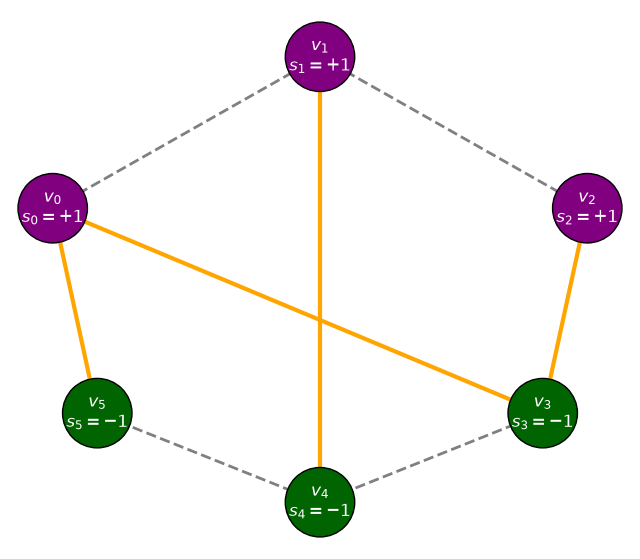

In [25]:
# Cycle graph C6 plus two connections
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

# positions for nodes in the graph for plotting to match my layout in Tikz
pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}

# worst spin configuration
spins = np.array([1, 1, 1, -1, -1, -1])

# Colour nodes
node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

# Separate cut and internal edges
cut_edges = []
internal_edges = []

for u, v in G.edges():
    if spins[u] != spins[v]:
        cut_edges.append((u, v))
    else:
        internal_edges.append((u, v))

plt.figure(figsize=(8,7))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=2500,
    edgecolors='black'
)

# Labels
labels = {i: f"$v_{i}$\n$s_{{{i}}}={spins[i]:+d}$" for i in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_color='white')

# Internal edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=internal_edges,
    edge_color='gray',
    style='dashed',
    width=2
)

# Cut edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=cut_edges,
    edge_color='orange',
    width=3
)

plt.axis('off')
plt.axis('equal')
plt.show()

We can make a plotting function without defining postions using `pos = nx.spring_layout(G, seed=13)` with a seed for reproducibility. Instead of inputing

`pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}`

We'll also make a spin-less/empty node graph function

In [26]:
def draw_empty_graph(G):
    pos = nx.spring_layout(G, seed=13)  

    n = G.number_of_nodes()
    
    node_colors = 'purple'

    all_edges = []

    for u, v in G.edges():
        all_edges.append((u, v))

    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    labels = {i: f"$v_{i}$" for i in G.nodes}
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=all_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    plt.axis('off')
    plt.axis('equal')
    plt.show()

And one with the cut edges defined once we input a spin.

In [27]:
def draw_graph_partition(G, spins):
    pos = nx.spring_layout(G, seed=13)  
    
    # Colour nodes
    node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

    # Separate cut and internal edges
    cut_edges = []
    internal_edges = []

    for u, v in G.edges():
        if spins[u] != spins[v]:
            cut_edges.append((u, v))
        else:
            internal_edges.append((u, v))

    n = G.number_of_nodes()
    
    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    labels = {}

    for i in G.nodes:
        arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
        labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
    
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=internal_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    # Cut edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=cut_edges,
        edge_color='orange',
        width=3
    )

    plt.axis('off')
    plt.axis('equal')
    plt.show()

In [233]:
def run_partition_graph_example(G, A, B, sweeps):
    print("Inputed graph:")
    draw_empty_graph(G)
    
    print(f"A={A}, B={B}")
    check_valid_AB(A, B, G)

    J, h = make_graph_partition(G, A, B)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    #setA, setB, cut_edges = decode_partition_solution(G, spins)
    
    draw_graph_partition(G, spins)

Inputed graph:


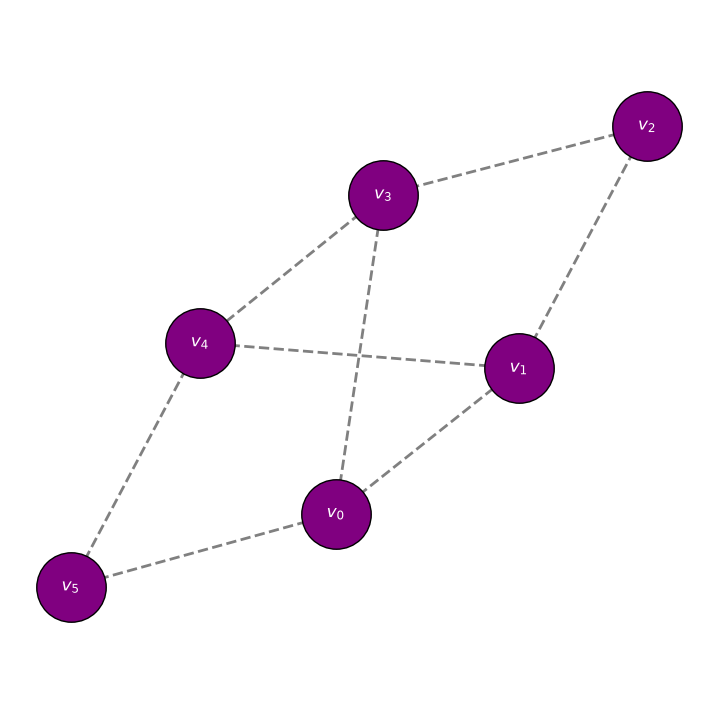

A=4, B=2
Max degree Δ=3,  bound A/|B| >= 0.750
Current A/|B| = 2.000  valid


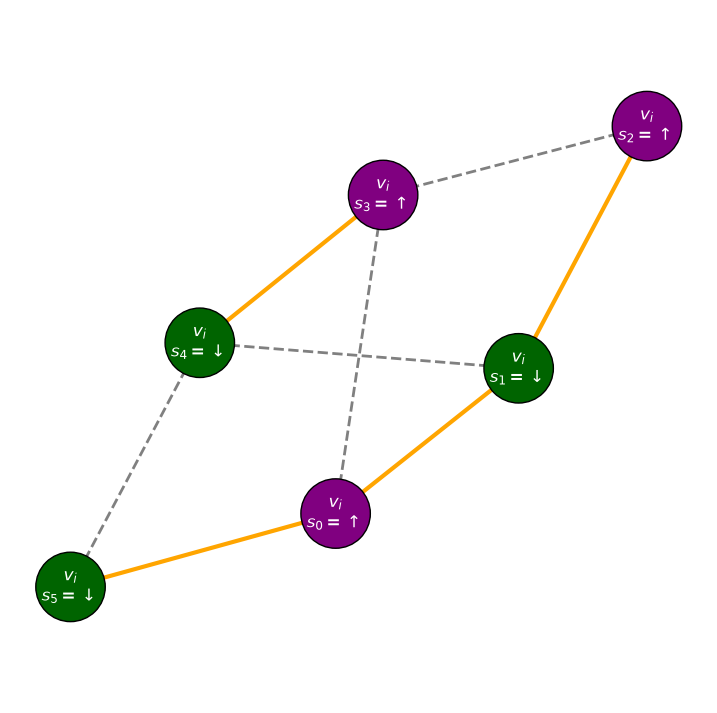

In [236]:
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

run_partition_graph_example(G, A=4, B=2, sweeps=1000)

That is solving the problem to minimise the cut edes, now we can try it with random $G(E,V)$
#### Random

In [239]:
def make_random_graph(lower,upper):
    # Random even number of vertices between 6 and 14
    n = random.choice(range(lower, upper, 2))

    # Create the cycle graph C_n
    G = nx.cycle_graph(n)

    # Number of extra edges to add
    num_extra = random.randint(2, n // 2) # divides by two and rounds down

    added = 0
    while added < num_extra:
        u, v = random.sample(range(n), 2)

        # Skip if edge already exists
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    print(f"n = {n}")
    print(f"Added {num_extra} extra edges")
    
    return G

def run_random_partition_graph_example(lower, upper):
    make_random_graph(lower,upper)
    run_partition_graph_example(G, A=4, B=2, sweeps=1000)

n = 56
Added 6 extra edges
Inputed graph:


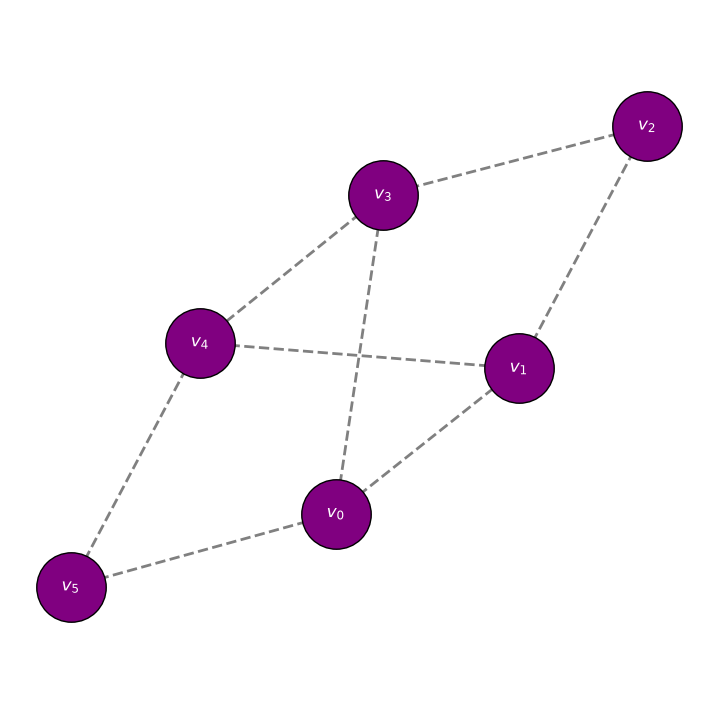

A=4, B=2
Max degree Δ=3,  bound A/|B| >= 0.750
Current A/|B| = 2.000  valid


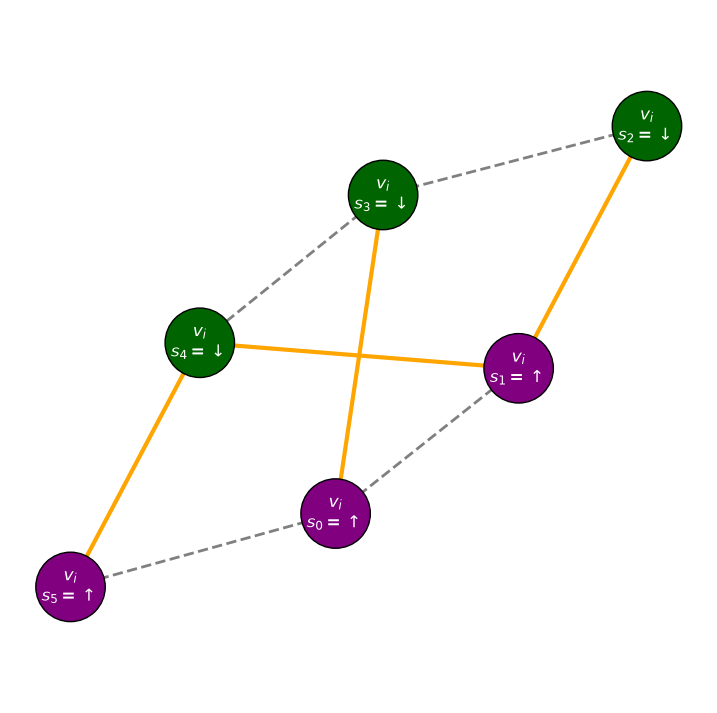

In [240]:
run_random_partition_graph_example(6, 100)

#### Animation

I think it'd be fun to plot the annealing process. We need to save the spin history in the annealing, then update our spins diagrams.

Redefining the annealing,



In [32]:
def sim_annealing_animation(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    history = []
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        history.append(s.copy())
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy(), history

In [33]:
def update(frame):
    
    ax.clear()
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    
    spins = history[frame]
    
    # Colour nodes
    node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

    # Separate cut and internal edges
    cut_edges = []
    internal_edges = []

    for u, v in G.edges():
        if spins[u] != spins[v]:
            cut_edges.append((u, v))
        else:
            internal_edges.append((u, v))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=1900,
        edgecolors='black',
        ax=ax
    )
    
    # Labels
    labels = {}
    
    for i in G.nodes:
        arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
        labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
    
    nx.draw_networkx_labels(
        G,
        pos,
        labels,
        font_color="white",
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=internal_edges,
        edge_color="gray",
        style="dashed",
        width=2,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cut_edges,
        edge_color="orange",
        width=3,
        ax=ax,
    )
    
    ax.set_title(
        f"Step {frame} | "
        f"T = {temps[frame]:.3f} | "
        f"E = {energies[frame]:.2f}",
        fontsize=16
    )
    
    ax.set_axis_off()
    ax.set_aspect("equal")
    
    

In [38]:
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

def run_partition_graph_animation(G):
    pos = nx.spring_layout(G, seed=13)

    # fix the axis limits to avoid rescaling during the animation
    x_values = [p[0] for p in pos.values()]
    y_values = [p[1] for p in pos.values()]

    margin = 0.5

    xlim = (min(x_values)-margin, max(x_values)+margin)
    ylim = (min(y_values)-margin, max(y_values)+margin)

    n = G.number_of_nodes()
    size = max(9, 0.8 * n)

    fig, ax = plt.subplots(figsize=(size, size))

    J, h = make_graph_partition(G, A=4, B=4)
    temps, energies, spins, history = sim_annealing_animation(
        J,
        h,
        T_start=10,
        T_end=0.1,
        alpha=0.99,
        sweeps_per_T=1000
        )

    history = history[::2]  # downsample the history for faster animation
    energies = energies[::2]  # downsample the energies for faster animation
    temps = temps[::2]  # downsample the temperatures for faster animation
    spins = spins[::2]  # downsample the spins for faster animation

    def update(frame):
        
        ax.clear()
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        
        spins = history[frame]
        
        # Colour nodes
        node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

        # Separate cut and internal edges
        cut_edges = []
        internal_edges = []

        for u, v in G.edges():
            if spins[u] != spins[v]:
                cut_edges.append((u, v))
            else:
                internal_edges.append((u, v))

        # Nodes
        nx.draw_networkx_nodes(
            G, pos,
            node_color=node_colors,
            node_size=1900,
            edgecolors='black',
            ax=ax
        )
        
        # Labels
        labels = {}
        
        for i in G.nodes:
            arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
            labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
        
        nx.draw_networkx_labels(
            G,
            pos,
            labels,
            font_color="white",
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=internal_edges,
            edge_color="gray",
            style="dashed",
            width=2,
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=cut_edges,
            edge_color="orange",
            width=3,
            ax=ax,
        )
        
        ax.set_title(
            f"Step {frame} | "
            f"T = {temps[frame]:.3f} | "
            f"E = {energies[frame]:.2f}",
            fontsize=16
        )
        
        ax.set_axis_off()
        ax.set_aspect("equal")
    
    
    
    animation = FuncAnimation(fig, update, frames=len(history), interval=500, repeat=False)
    
    return animation

In [35]:
# display the animation in the notebook
# display(HTML(animation.to_jshtml()))

# download the animation as a GIF
'''
animation.save(
    "annealing.gif",
    writer=PillowWriter(fps=10)
)
'''

'\nanimation.save(\n    "annealing.gif",\n    writer=PillowWriter(fps=10)\n)\n'

In [36]:
def run_random_partition_graph_animation(lower, upper):
    # Random even number of vertices between 6 and 14
    n = random.choice(range(lower, upper, 2))

    # Create the cycle graph C_n
    G = nx.cycle_graph(n)

    # Number of extra edges to add
    num_extra = random.randint(2, n // 2) # divides by two and rounds down

    added = 0
    while added < num_extra:
        u, v = random.sample(range(n), 2)

        # Skip if edge already exists
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    print(f"n = {n}")
    print(f"Added {num_extra} extra edges")

    anim_random = run_partition_graph_animation(G)
    
    return anim_random

n = 16
Added 6 extra edges


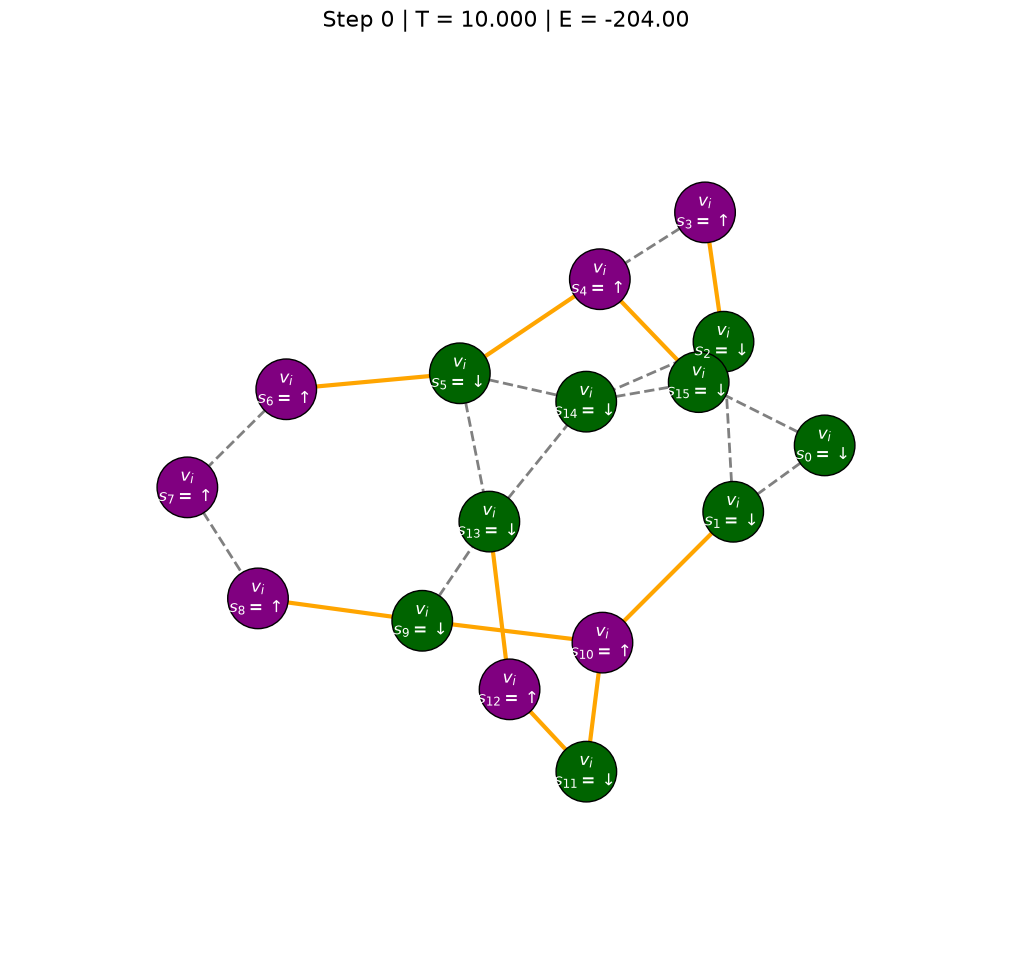

In [39]:
anim = run_random_partition_graph_animation(10, 35)
anim.save(
    "annealing.gif",
    writer=PillowWriter(fps=10)
)

These seem to work, they're a nice display of the annealing process.

# QUBO annealing
Importing the solving functions from`QUBO-anneal.pynb`, this is less optimised than my ising model code. All we've done is redefine the energy function and sweeping functions.

In [225]:
@njit
def energy_QUBO(x, Q):
    return x @ Q @ x

@njit
def sweep_once_QUBO(x, Q, T, E):
    N = len(x)
    for _ in range(N):
        i = np.random.randint(N) 

        old_bit = x[i]
        x[i] = 1 - x[i]  # Flip the binary spin (0 to 1 or 1 to 0)
        
        # Calculate the change in energy if we flip spin i
        new_E = energy_QUBO(x, Q)
        delta_E = new_E - E
        
        # Metropolis criterion
        if delta_E < 0 or np.random.rand() < np.exp(-delta_E / T):
            E = new_E  # Accept the new configuration
        else:
            x[i] = old_bit  # Revert the flip if not accepted  
            
    return E

def sim_annealing_QUBO(Q, T_start, T_end, alpha, sweeps_per_T):
    n = Q.shape[0]
    x = np.random.choice(np.array([0, 1]), size=n).astype(np.float64)

    E = energy_QUBO(x, Q)

    temps = []
    energies = []
    
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once_QUBO(x, Q, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), x.copy()

We also have a small brute force checker to compare to our annealing results, I believe its only feasable for 2-4 Qs.

In [159]:
def brute_force_qubo(Q):
    n = Q.shape[0]

    best_energy = np.inf # set  to infiniy  
    best_x = None

    for x in product([0, 1], repeat=n): #produce generate all possible binary configurations of length n
        x = np.array(x, dtype=np.int8)
        E = x @ Q @ x

        if E < best_energy:
            best_energy = E
            best_x = x.copy()

    return best_energy, best_x

# Binary Integer Linear Programming (BILP)

This class of problems is the next jump, we define the problem.

We have N binary variables $\vec x\in\{0,1\}^N$ which we want to arange into a vector $\vec x$ such that we maximise $\vec c \cdot \vec x$, given the restraint $S \vec x = \vec b$.

Where $S$ is a $m\times N$ matrix and $\vec b \in$ is a vector with m components.



Now taking a classic ILP problem is defined like,

$\underset{x,y \in \mathbb{Z}}{\text{maximize}} \quad  y$
subject to 
$\quad -x +y \leq 1, 3x + 2y \leq 12, 2x + 3y \leq 12, x,y \ge 0$


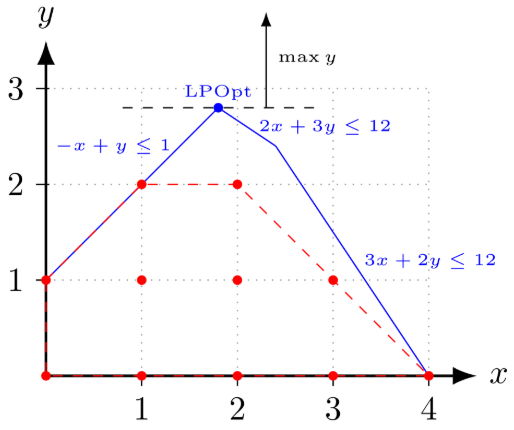

This is is a nice way of visulising our solution, however for our binary version there is no interior.

Now take some vector $\vec x=\begin{pmatrix}x_1\\x_2\\x_3\end{pmatrix}$ 

where $x_i\in\{0,1\}$ so our solutions are a cube with the corners being the solutions. So for N binary variables $\vec x\in\{0,1\}^N$ we have a  ***N*** *hyper-cube* for our solutions with no interior, so the classic ILP diagrams don't really help to visualise.


***Back to QUBO***

Now, we swap from ising formulation of $s=\begin{cases}1\\-1\end{cases}$ into a binary representation $x=\begin{cases}0\\1\end{cases}$

This can be done with the transformation, $x_i\rightarrow \frac{1+s_i}{2}$

Now like last time we will have two components to $H=H_A+H_B$

$H_A=A\sum_{j=1}^m\left(b_j-\sum_{i=1}^N S_{ji}x_i\right)^2$ this will enforce $S \vec x = \vec b$

&

$H_B = -B\sum_{i=1}^Nc_ix_i$ which will maximise $\vec c \cdot \vec x$


There exists conditions on $A$ and $B$ where $\frac{A}{B}\gtrsim N$

$H_A=\sum_{i=1}^N~\underbrace{A\sum_{j=1}^m(S_{ji}^2-2b_jS_{ji})}_{h_i}x_i+ \sum_{i<k}^N~\underbrace{2A\sum_{j=1}^mS_{ji}S_{jk}}_{J_{ij}}x_ix_k$

$H_B =\sum_{i=1}^N\underbrace{-Bc_i}_{h_i}x_i$

$Q_{ii}=A\sum_{j=1}^m(S_{ji}^2-2b_jS_{ji}) -Bc_i$

and

$Q_{ij}=2A\sum_{j=1}^mS_{ji}S_{jk}$

here we've swapped to $Q_{ij}$ instead of $J_{ij}$ since we have binary inputs rather than spins.

In [85]:
def make_BILP(S,b,c, A, B):
    # S is  mxn matrix of coefficients for constraints
    # b is m vector of constants for constraints
    # c is n vector of coefficients for the objective function
    
    m, N = S.shape
    Q = np.zeros((N, N))
    
    #diagonal terms  
    for i in range(N):
        Q[i,i] += A * np.sum(S[:,i]**2 - 2*b*S[:,i])  - B * c[i]
    
    # off-diagonal terms
    for i in range(N):
        for j in range(i+1, N):
            Q[i,j] += 2 * A * np.sum(S[:,i] * S[:,j])
            Q[j,i] = Q[i,j]
            
    return Q

def read_BILP(x, c, S, b, verbose):
    # x is a binary vector of length N
    # c is a vector of length N
    # S is a mxN matrix of coefficients for constraints
    # b is a vector of length m

    objective_value = c @ x
    constraint_values = S @ x
    residuals = constraint_values - b
    feasible = np.allclose(residuals, 0)
   
    print(f"x = {x.astype(int)}")
    
    if verbose:
    
        print(f"Objective value c·x = {objective_value}")
        #print(f"Constraint values Sx = {constraint_values}")
        print(f"Residuals Sx - b = {residuals}  (should be 0)")
        print(f"Feasible: {feasible}")

    return objective_value, constraint_values, residuals

In [226]:
def compare_brute_force_and_annealing(Q, S, b, c):
    Q = make_BILP(S, b, c, A, B)
    print("Q =\n", Q)
    # Brute force verify
    brute_E, brute_x = brute_force_qubo(Q)
    print("\nBrute force solution:")
    read_BILP(brute_x, c, S, b, False)
    #print(f"Brute force energy: {brute_E}")

    # Simulated annealing
    temps, energies, x_anneal = sim_annealing_QUBO(
        Q, 
        T_start=10.0, 
        T_end=0.01,
        alpha=0.95, 
        sweeps_per_T=1000
    )
    
    print("\nSimulated annealing solution:")
    read_BILP(x_anneal, c, S, b, False)
    #print(f"Annealing energy: {w}")
    
    def_x = brute_x - x_anneal
    same = np.allclose(def_x, 0)
    print(f"\nThe brute force and annealing are the same: {same}")

In [87]:
S = np.array([[1, 1, 1]], dtype=float)   # x1 + x2 + x3 = 1
b = np.array([1,0])
c = np.array([3.0, 1.0, 2.0])           # maximise 3x1 + x2 + 2x3

A=2.0
B=1.0

compare_brute_force_and_annealing(Q, S, b, c)


Q =
 [[-3.  4.  4.]
 [ 4. -1.  4.]
 [ 4.  4. -2.]]

Brute force solution:
x = [1 0 0]

Simulated annealing solution:
x = [1 0 0]

The brute force and annealing are the same: True


In [227]:
def random_BILP(m, N, seed=None,repeat=3):
    # instead of np.random reproducable
    rng = np.random.default_rng(seed)

    # Random feasible binary solution
    x_true = rng.integers(0, 2, size=N)
    
    print("x true", x_true)
    
    # Random constraint matrix
    S = rng.integers(-2, 3, size=(m, N)).astype(float)

    # Compute b so x_true is feasible
    b = S @ x_true

    # Random objective
    c = rng.integers(-5, 6, size=N).astype(float)

    A = 10 * np.sum(np.abs(c)) / np.min(np.sum(np.abs(S), axis=1))
    B = 1

    Q = make_BILP(S, b, c, A=A, B=B)
    
    print("Our Q matrix:")
    print (Q)
    
    print("x_true:", x_true)
    print("Feasible?", np.allclose(S @ x_true, b))
    print("Objective:", c @ x_true)
    
    for i in range(repeat):
        temps, energies, x_anneal = sim_annealing_QUBO(
            Q, 
            T_start=20.0, 
            T_end=1e-4,
            alpha=0.99, 
            sweeps_per_T=sweeps
        )
        
        print("\nSimulated annealing solution:", {i+1})
        read_BILP(x_anneal, c, S, b, True)
        #print("x:", x_anneal[:N])
        #print("Constraint residual:", S @ x_anneal[:N] - b)
        print("Objective:", c @ x_anneal[:N])

'''
for j in range(2,4,4):
    print("\n===== N =", j, "=====")
    sweeps = 2000 * j
    random_BILP(j, j, seed=42)
'''

'\nfor j in range(2,4,4):\n    print("\n===== N =", j, "=====")\n    sweeps = 2000 * j\n    random_BILP(j, j, seed=42)\n'

This last randomisation doesn't work, I believe its due to the values of $A$ and $B$, currently 

`A = 10 * np.sum(np.abs(c)) / np.min(np.sum(np.abs(S), axis=1))` `B=1`

doesn't seem to work.

We're going to move on cause BILP doesn't offer much more to our end goals.

# Graph Colouring

Lets take another undirected graph $G(V,E)$ and $n$ colours. Can we colour each vertex such that no edge connects vertices of the same colour? This is a generaliseation of the famous how many colours are needed to colour a map such that no two countries of the same colour share a border, ($n\geq 4$).

<a id="ref-appel1"></a>
[Appel and Haken 1977a] Appel, K. and Haken, W. *Every planar map is four colorable. I. Discharging*. Illinois Journal of Mathematics, **21**, 429–490 (1977).

<a id="ref-appel2"></a>
[Appel et al. 1977b] Appel, K., Haken, W., and Koch, J. *Every planar map is four colorable. II. Reducibility*. Illinois Journal of Mathematics, **21**, 491–567 (1977).

We introduce two index binary variables $x_{v,i}$ which will be one if vertex $v\in V$ has colour $i$ or its $0$.

We build a similar idea to previous examples with,

$H_{A,1}= A \sum_v\left(1-\sum_{i=1}^nx_{v,i}\right)^2$ 

which enforces that each index has one colour, penalising otherwise.

Then, 
$H_{A,2}= A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$

adds a penalty for one colour $i$ connecting two vertices $u$ and $v$.

$H=A \sum_v\left(1-\sum_{i=1}^nx_{v,i}\right)^2 +A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$

Now expanding our our square to read off our $Q$ matrix,

$H_{A,1}A=\sum_v \left(1 - \sum_i x_{v,i}\right)^2 
= A\sum_v\left(\underbrace{1}_{\text{drop}} - \sum_i x_{v,i} + \left(\sum_i x_{v,i}\right)^2\right)$

$= A\sum_v\left( - \sum_i x_{v,i} + 2\sum_{i<j} x_{v,i}x_{v,j}\right)$

and then $H_{A,2}$ is already quadratic,
$A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$



$H=A\sum_v\left(- \sum_i x_{v,i} + 2\sum_{i<j} x_{v,i}x_{v,j}\right) +A \sum_{(u,v)\in E}\sum_{i=1}^nx_{u,i}x_{v,i}$

We need to flatten the indices out $(v,i)\rightarrow k=v\cdot n +i$, then we adjust our entries

In [ ]:
def idx(v, i, n):
    return v * n + i    

def build_graph_colour(G,n_colours, A=1.0):
    
    N = G.number_of_nodes()
    n = n_colours
    
    nodes = list(G.nodes())
    node_idx = {v: i for i, v in enumerate(nodes)}
 
    Q = np.zeros((N * n, N * n))
    
    for v in range(N):
        for i in range(n):
        # diagonal: -A for every (v,i)
            Q[idx(v,i,n), idx(v,i,n)] -= A
        
        for i in range(n):
           for j in range(i+1,n):
            # same vertex, different colours: +2A
                Q[idx(v,i,n), idx(v,j,n)] += 2*A    
                
    for u,v in G.edges():
        u_idx = node_idx[u]
        v_idx = node_idx[v]
        
        for i in range(n):
        # edge conflict, same colour: +A
            Q[idx(u_idx,i,n), idx(v_idx,i,n)] += A
            Q[idx(v_idx,i,n), idx(u_idx,i,n)] += A
            
    return Q

def read_graph_colour(G, x, n_colours):
    nodes = list(G.nodes())
    N = len(nodes)
    n = n_colours
    
    colouring = {}
    valid = True

    # check multiple coloura
    for v in range(N):
        colours_assigned = [i for i in range(n) if x[idx(v,i,n)] == 1]
        if len(colours_assigned) != 1:
            print(f"vertex {nodes[v]}: invalid assignment {colours_assigned}")
            valid = False
        else:
            colouring[nodes[v]] = colours_assigned[0] # stores the colour
            
    # check edges
    conflicts = [(u,v) for u,v in G.edges() if colouring.get(u) == colouring.get(v)]
    

    print(f"Colouring: {colouring}")
    print(f"Conflicts: {conflicts}")
    print(f"Valid: {valid and len(conflicts) == 0}")
    return colouring , valid    

In [ ]:
G = nx.cycle_graph(4)   # 4-cycle needs 2 colours
n_colours = 2

Q = build_graph_colour(G, n_colours, A=1.0)
best_E, best_x = brute_force_qubo(Q)

read_graph_colour(G, best_x, n_colours)

Colouring: {0: 1, 1: 0, 2: 1, 3: 0}
Conflicts: []
Valid: True


({0: 1, 1: 0, 2: 1, 3: 0}, True)

In [ ]:
def plot_graph_colouring(G, colouring, valid, energy):

    if not valid:
        print("Cannot plot: colouring is invalid.")
        return

    palette = [
        "tab:blue",
        "tab:orange",
        "tab:green",
        "tab:red",
        "tab:purple",
        "tab:brown",
        "tab:pink",
        "tab:gray",
        "tab:olive", A
X
(uv)∈/E
X
N
j=1
xu,jxv,j+1.
        "tab:cyan",
    ]

    node_colours = [palette[colouring[v]] for v in G.nodes()]

    pos = nx.spring_layout(G, seed=1)

    plt.figure(figsize=(5,5))

    nx.draw_networkx_edges(G, pos, width=2)
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colours,
        node_size=800,
        edgecolors="black",
    )
    nx.draw_networkx_labels(G, pos)

    plt.title(f"Graph colouring\nEnergy = {energy}")
    plt.axis("off")
    plt.show()

n = 13
Added 4 extra edges
We have 1 colours.
vertex 0: invalid assignment []
vertex 2: invalid assignment []
vertex 4: invalid assignment []
vertex 5: invalid assignment []
vertex 7: invalid assignment []
vertex 9: invalid assignment []
vertex 11: invalid assignment []
Colouring: {1: 0, 3: 0, 6: 0, 8: 0, 10: 0, 12: 0}
Conflicts: [(4, 5), (4, 11), (5, 7), (5, 11), (7, 9)]
Valid: False
We have 2 colours.
vertex 7: invalid assignment []
vertex 11: invalid assignment []
Colouring: {0: 1, 1: 0, 2: 1, 3: 0, 4: 1, 5: 0, 6: 1, 8: 0, 9: 1, 10: 0, 12: 0}
Conflicts: []
Valid: False
We have 3 colours.
Colouring: {0: 2, 1: 0, 2: 2, 3: 0, 4: 1, 5: 0, 6: 2, 7: 1, 8: 0, 9: 2, 10: 0, 11: 2, 12: 1}
Conflicts: []
Valid: True


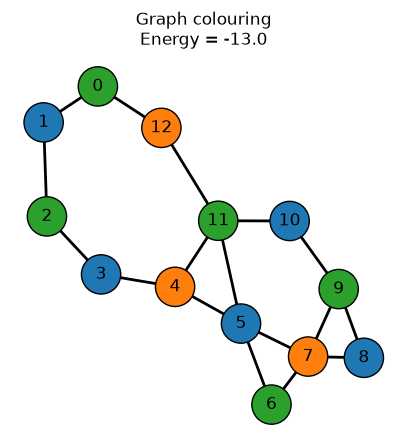

In [273]:
G = make_random_graph(9, 14)

valid = False
n_colours = 1

while not valid:

    print(f"We have {n_colours} colours.")

    Q = build_graph_colour(G, n_colours, A=1.0)

    temps, energies, spins = sim_annealing_QUBO(
        Q,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=1000,
    )

    best_x = spins
    best_E = energies[-1]

    colouring, valid = read_graph_colour(
        G,
        best_x,
        n_colours,
    )

    if not valid:
        n_colours += 1

plot_graph_colouring(G, colouring, valid, best_E)

# Hamiltonian Cycle/Path

 This is a generalisation of the famous *Seven Bridges of Konigsberg* which asked could you make it around the 7 bridges of the ciry without crossing the same bridge twice. Many mathmaticians like Euler attempted this,

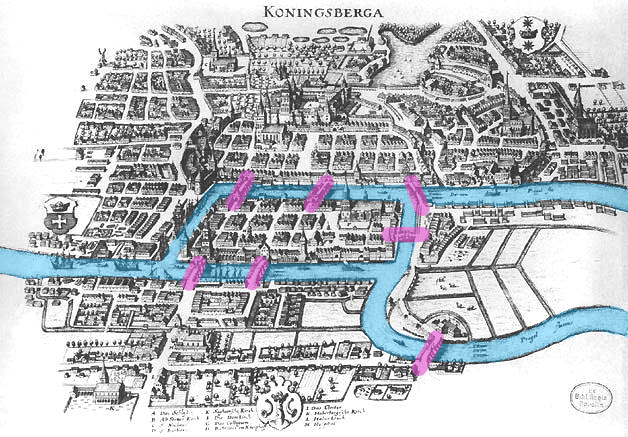

The Hamiltonian Path problem generalises this for some graph, $G(E,V)$ and $V=|N|$ (directed or undirected), can we start at one node and vist every node in the graph without returning to any node twice? If we enforce returning to the same point this becomes the Hamiltonian Cycle problem.


Now we label the vertices $v\in V$, $(1,2,\cdots,N)$, and the edges $(uv)\in E$ 

$\left[   (uv) \text{ directed order mattes, we can extend to undirected by adding} (vu) \text{whenever }(uv) \text{ is added to } E  \right]$ 

Our binary bits are $x_{v,i}$ where $v\in V$ is our vertex and $i$ is the order of the path/cycle. Our energy function will have three componets, $H=H_1+H_2+H_3$ , and will look similar to previous functions we've looked at.

Now $H_1$ will enforce that every vertice can only appear once in path/cycle,

$H_{1}= A \sum_{v=1}^n\left(1-\sum_{j=1}^Nx_{v,j}\right)^2$ 

$= A\sum_{v=1}^n\left(\underbrace{1}_{\text{drop}} - \sum_i^N x_{v,j} + \left(\sum_i^N x_{v,j}\right)^2\right)$

$= A\sum_{v=1}^n\left( - \sum_i^N x_{v,j} + 2\sum_{i<j}^N x_{v,i}x_{v,j}\right)$

Next, $H_2$ will enforce that there must be a $j^\text{th}$ node in the cycle/path for each $j$. 

$H_2=A \sum_{j=1}^N\left(1-\sum_{v=1}^nx_{v,j}\right)^2$

$H_2
=A\sum_{j=1}^{N}\left(\underbrace{1}_{\text{drop}}-2\sum_{v=1}^{n}x_{v,j}+\left(\sum_{v=1}^{n}x_{v,j} \right)^2\right)$

$=A\sum_{j=1}^{N}\left(-\sum_{v=1}^{n}x_{v,j}+2\sum_{u<v}^nx_{u,j}x_{v,j}\right)$

Finally, $H_3$ will need to penalise edges if we take $x_{u,j}$ and $x_{v,j+1}$ which are both one then we need to penalise this if $(u,v)\notin E$

$H_3=A\sum_{(uv)\notin E}\sum_{j=1}^N x_{u,j}x_{v,j+1}$

Combing this we get

$H_A=H_1+H_2+H_3$

$=A\sum_{v=1}^n\left( - \sum_i^N x_{v,j}\\ + 2\sum_{i<j}^N x_{v,i}x_{v,j}\right)\\
~~ + A\sum_{j=1}^{N}\left(-\sum_{v=1}^{n}x_{v,j}+2\sum_{u<v}^nx_{u,j}x_{v,j}\right)\\
~~ + A\sum_{(uv)\notin E}\sum_{j=1}^N x_{u,j}x_{v,j+1}$



In [ ]:
def idx(v, j, N):
    return v * N + j

def build_hamiltonian_cycle(G,A):
    N = G.number_of_nodes()
    Q = np.zeros((N*N, N*N))

    #nodes = list(G.nodes())
    #node_idx = {v: j for j, v in enumerate(nodes)}


    for v in range(N):
        # diagonal
        for j in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for j1 in range(N):
            for j2 in range(j1+1, N):
                Q[idx(v,j1,N), idx(v,j2,N)] += 2*A
                Q[idx(v,j2,N), idx(v,j1,N)] += 2*A
                
    for j in range(N):

        # diagonal
        for v in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for u in range(N):
            for v in range(u+1, N):
                Q[idx(u,j,N), idx(v,j,N)] += 2*A
                Q[idx(v,j,N), idx(u,j,N)] += 2*A
                
    for u in range(N):
        for v in range(N):

            if u == v:
                continue

            if not G.has_edge(u, v):

                for j in range(N):

                    jp = (j + 1) % N      # wrap around for Hamiltonian cycle

                    Q[idx(u,j,N), idx(v,jp,N)] += A
                    Q[idx(v,jp,N), idx(u,j,N)] += A
    return Q


def read_hamiltonian_cycle(G,x):

    N = G.number_of_nodes()

    cycle = [None] * N
    valid = True
    
    # each vertex appears once
    for v in range(N):

        positions = [j for j in range(N) if x[idx(v, j, N)] == 1]

        if len(positions) != 1:
            print(f"Vertex {v}: invalid positions {positions}")
            valid = False
        else:
            cycle[positions[0]] = v

    # each position is filled once
    for j in range(N):

        vertices = [v for v in range(N) if x[idx(v, j, N)] == 1]

        if len(vertices) != 1:
            print(f"Position {j}: invalid vertices {vertices}")
            valid = False

    # graph edges
    missing_edges = []

    if valid:

        for j in range(N):

            u = cycle[j]
            v = cycle[(j + 1) % N]

            if not G.has_edge(u, v):
                missing_edges.append((u, v))

        if missing_edges:
            valid = False

    print(f"Cycle: {cycle}")
    print(f"Missing edges: {missing_edges}")
    print(f"Valid: {valid}")

    return cycle, valid

In [ ]:
G = nx.cycle_graph(4)
A = 1.0

Q = build_hamiltonian_cycle(G, A)
'''
best_E, best_x = brute_force_qubo(Q)

print("brute")
cycle, valid = read_hamiltonian_cycle(G, best_x)
'''
temps, energies, anneal_x = sim_annealing_QUBO(
        Q,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=1000,
    )

print("anneal")
cycle, valid = read_hamiltonian_cycle(G, anneal_x)


anneal
Cycle: [3, 0, 1, 2]
Missing edges: []
Valid: True


Now, we want to plot this.

In [ ]:
def plot_hamiltonian_cycle(G, cycle, valid):

    if not valid:
        print("Cannot plot: invalid Hamiltonian cycle.")
        return

    pos = nx.spring_layout(G, seed=1)

    plt.figure(figsize=(6,6))

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="lightgrey",
        width=2
    )

    cycle_edges = []

    N = len(cycle)

    for i in range(N):
        u = cycle[i]
        v = cycle[(i + 1) % N]
        _edges.append((u, v))

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cycle_edges,
        edge_color="green",
        width=4
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color="pink",
        node_size=700,
        edgecolors="black"
    )
    
    nx.draw_networkx_labels(G, pos)

    plt.title("Hamiltonian Cycle")
    plt.axis("off")
    plt.show()

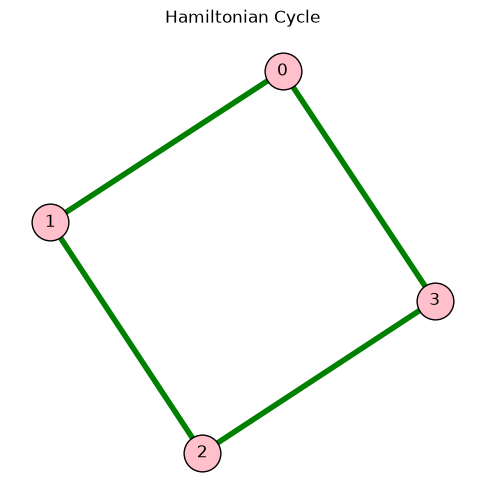

In [312]:
plot_hamiltonian_cycle(G, cycle, valid)

In [ ]:
def hamiltonian_anneal(G):
    A = 8.0

    Q = build_hamiltonian_cycle(G, A)
    temps, energies, anneal_x = sim_annealing_QUBO(
            Q,
            T_start=10,
            T_end=0.01,
            alpha=0.99,
            sweeps_per_T=1000,
        )

    print("anneal")
    cycle, valid = read_hamiltonian_cycle(G, anneal_x)
    
    return temps, energies, anneal_x , cycle, valid

Lets try it with the bridge problem,


MultiGraph with 4 nodes and 7 edges
anneal
Cycle: [1, 2, 0, 3]
Missing edges: []
Valid: True


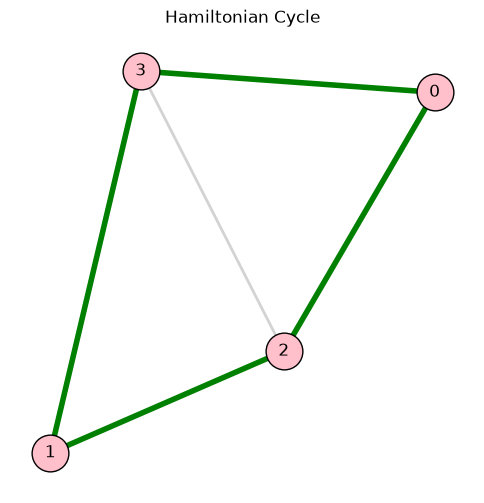

In [ ]:
# 4 landmasses as nodes
# A = North bank, B = South bank, C = Kneiphof island, D = East bank
# 0=North(A), 1=South(B), 2=Island(C), 3=East(D)

G = nx.MultiGraph()
G.add_nodes_from([0, 1, 2, 3])  # 0=A, 1=B, 2=C, 3=D

G.add_edges_from([
    (0, 2), (0, 2),  # A-C x2
    (1, 2), (1, 2),  # B-C x2
    (0, 3),          # A-Ddef idx(v, j, N):
    return v * N + j

def build_hamiltonian_cyce(G,A):
    N = G.number_of_nodes()
    Q = np.zeros((N*N, N*N))

    #nodes = list(G.nodes())
    #node_idx = {v: j for j, v in enumerate(nodes)}


    for v in range(N):
        # diagonal
        for j in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for j1 in range(N):
            for j2 in range(j1+1, N):
                Q[idx(v,j1,N), idx(v,j2,N)] += 2*A
                Q[idx(v,j2,N), idx(v,j1,N)] += 2*A
                
    for j in range(N):

        # diagonal
        for v in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for u in range(N):
            for v in range(u+1, N):
                Q[idx(u,j,N), idx(v,j,N)] += 2*A
                Q[idx(v,j,N), idx(u,j,N)] += 2*A
                
    for u in range(N):
        for v in range(N):

            if u == v:
                continue

            if not G.has_edge(u, v):

                for j in range(N):

                    jp = (j + 1) % N      # wrap around for Hamiltonian cycle

                    Q[idx(u,j,N), idx(v,jp,N)] += A
                    Q[idx(v,jp,N), idx(u,j,N)] += A
                    
    for u in range(N):
        for v in range(N):
            if u == v:
                continue

            if G.has_edge(u, v):
                or j in range(N):
            
    return Q

    (1, 3),          # B-D
    (2, 3),          # C-D
])

print(G)
temps, energies, anneal_x , cycle, valid =hamiltonian_anneal(G)
plot_hamiltonian_cycle(G, cycle, valid)


n = 9
Added 4 extra edges
Graph with 9 nodes and 13 edges
anneal
Cycle: [5, 6, 7, 8, 0, 1, 2, 3, 4]
Missing edges: []
Valid: True


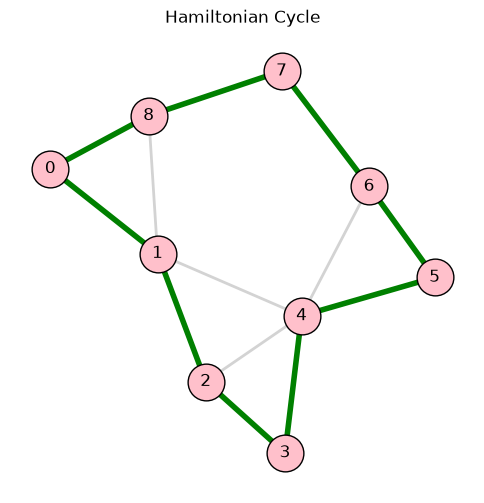

In [321]:
G = make_random_graph(9, 14)

print(G)
temps, energies, anneal_x , cycle, valid =hamiltonian_anneal(G)
plot_hamiltonian_cycle(G, cycle, valid)


# Travelling Salesman Problem

We take a hamiltion cycle graph $G(V,E)$, now each edge $(uv)$ has some weight $W_{uv}$ associated to each edge. Now we want to minimise the sum of he weights of each edge in the cycle.

$H_B= B\sum_{(uv)\in E}W_{uv}\sum_{j=1}^Nx_{u,j}x_{v,j+1}$

We need to ensure that the $H_A$ for the hamiltonian cycle is never violated, hence 

$0<B\max(W_{uv})<A$

So putting it all together,

$H= H_A+H_B=\\
~~=A\sum_{v=1}^n\left( - \sum_i^N x_{v,j}\\ + 2\sum_{i<j}^N x_{v,i}x_{v,j}\right)\\
~~ + A\sum_{j=1}^{N}\left(-\sum_{v=1}^{n}x_{v,j}+2\sum_{u<v}^nx_{u,j}x_{v,j}\right)\\
~~ + A\sum_{(uv)\notin E}\sum_{j=1}^N x_{u,j}x_{v,j+1}\\
~~ + B\sum_{(uv)\in E}W_{uv}\sum_{j=1}^Nx_{u,j}x_{v,j+1}$



In [ ]:
def idx(v, j, N):
    return v * N + j

def build_tsp(G,A,B):
    N = G.number_of_nodes()
    Q = np.zeros((N*N, N*N))

    # hamiltionan cycle code
    for v in range(N):
        # diagonal
        for j in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for j1 in range(N):
            for j2 in range(j1+1, N):
                Q[idx(v,j1,N), idx(v,j2,N)] += 2*A
                Q[idx(v,j2,N), idx(v,j1,N)] += 2*A
                
    for j in range(N):

        # diagonal
        for v in range(N):
            Q[idx(v,j,N), idx(v,j,N)] -= A
        # off-diagonal
        for u in range(N):
            for v in range(u+1, N):
                Q[idx(u,j,N), idx(v,j,N)] += 2*A
                Q[idx(v,j,N), idx(u,j,N)] += 2*A
                
    for u in range(N):
        for v in range(N):

            if u == v:
                continue

            if not G.has_edge(u, v):

                for j in range(N):

                    jp = (j + 1) % N   

                    Q[idx(u,j,N), idx(v,jp,N)] += A/2# symmetric
                    Q[idx(v,jp,N), idx(u,j,N)] += A/2#symmetric
     
     
    # additional H_B term for TSP  
    weights = nx.get_edge_attributes(G, 'weight')
        
    for u in range(N):
        for v in range(N):
            if u == v:
                continue

            if G.has_edge(nodes[u], nodes[v]):
                w = weights.get((nodes[u], nodes[v]),
                    weights.get((nodes[v], nodes[u]), 1.0))
                for j in range(N):
                    jp = (j + 1) % N
                    Q[idx(u,j,N), idx(v,jp,N)] += B * w
                    Q[idx(v,jp,N), idx(u,j,N)] += B * w   
    return Q


In [368]:
def read_tsp(G, x, verbose=False):

    N = G.number_of_nodes()
    cycle = [None] * N
    valid = True

    for v in range(N):
        positions = [j for j in range(N) if x[idx(v, j, N)] == 1]
        if len(positions) != 1:
            print(f"Vertex {v}: invalid positions {positions}")
            valid = False
        else:
            cycle[positions[0]] = v

    for j in range(N):
        vertices = [v for v in range(N) if x[idx(v, j, N)] == 1]
        if len(vertices) != 1:
            print(f"Position {j}: invalid vertices {vertices}")
            valid = False

    missing_edges = []
    total_weight = 0.0

    if valid:
        for j in range(N):
            u = cycle[j]
            v = cycle[(j + 1) % N]
            if not G.has_edge(u, v):
                missing_edges.append((u, v))
            else:
                total_weight += G[u][v]['weight']

        if missing_edges:
            valid = False
            
    if verbose == True:
        print(f"Cycle: {cycle}")
        print(f"Missing edges: {missing_edges}")
        print(f"Total weight: {total_weight:.2f}")
        print(f"Valid: {valid}")

    return cycle, valid

In [378]:
def tsp_anneal(G,A,B, T_start ,T_end , alpha , sweeps_per_T):

    Q = build_tsp(G, A,B)
    temps, energies, anneal_x = sim_annealing_QUBO(
            Q,
            T_start,
            T_end,
            alpha,
            sweeps_per_T,
        )

    print("anneal")
    cycle, valid = read_tsp(G, anneal_x)
    
    return temps, energies, anneal_x , cycle, valid

In [383]:
def plot_tsp(G, cycle, valid):
    if not valid:
        print("Cannot plot: invalid TSP cycle.")
        return

    pos = nx.spring_layout(G, seed=1)
    plt.figure(figsize=(6, 6))

    # all edges in grey
    nx.draw_networkx_edges(G, pos, edge_color="lightgrey", width=2)

    # cycle edges in green
    cycle_edges = []
    N = len(cycle)
    for i in range(N):
        u = cycle[i]
        v = cycle[(i + 1) % N]
        cycle_edges.append((u, v))

    nx.draw_networkx_edges(
        G, pos,
        edgelist=cycle_edges,
        edge_color="green",
        width=4
    )

    # nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color="pink",
        node_size=700,
        edgecolors="black"
    )
    nx.draw_networkx_labels(G, pos)

    # edge weight labels
    weights = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels={k: f"{v:.1f}" for k, v in weights.items()},
        rotate=False
    )

    total = sum(G[cycle[i]][cycle[(i+1) % N]]['weight'] for i in range(N))
    
    plt.title(f"TSP Cycle  |  total weight = {total:.2f}")
    plt.axis("off")
    plt.show()
    return total

Remember $0<B\max(W_{uv})<A$, so lets let $B=1$ $A=C\cdot B\cdot\max(W_{uv})$,

we need to tweak $C$ such that we always get a valid state and the lowest $\sum_{(uv)\in E} W_{uv}$.

We want to plot $E$ vs $T$ as it anneals to get an idea of annealing.

In [ ]:
def plot_TvE(temps, energies):
    plt.figure(figsize=(8, 4))
    plt.plot(temps, energies, color='steelblue', linewidth=1)
    plt.xlabel('Temperature')
    plt.ylabel('Energy')
    plt.title('Energy vs Temperature')
    plt.xscale('log')
    plt.gca().invert_xaxis()  # time flows left to right: hot → cold
    plt.axhline(y=min(energies), color='red', linestyle='--', 
                label=f'min E = {min(energies):.2f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

A: 90.0
Brute force minimum energy: -690.00
run 1

anneal


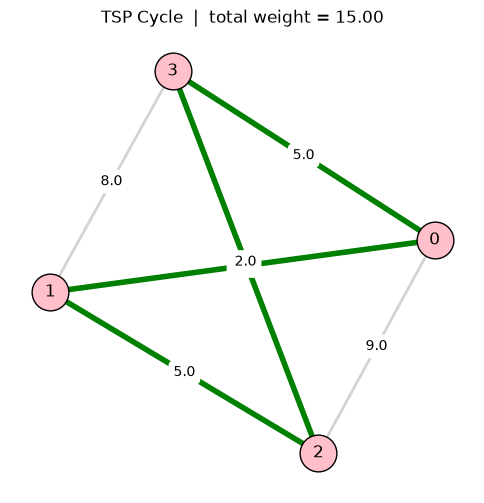

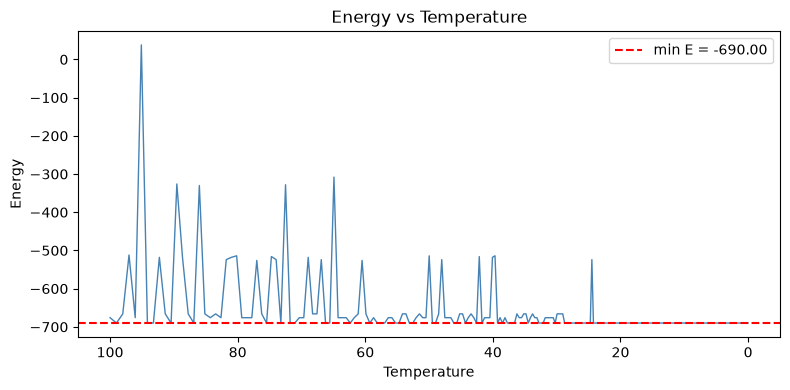

that gives us  sum of W=None
run 2

anneal


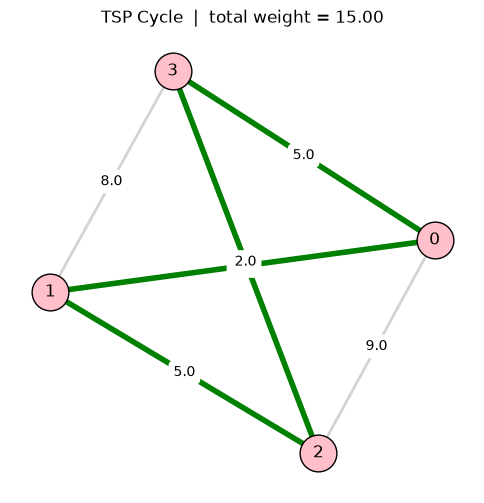

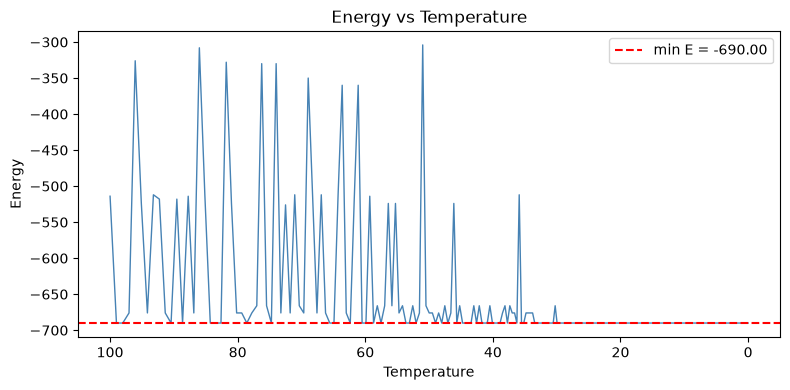

that gives us  sum of W=None
run 3

anneal


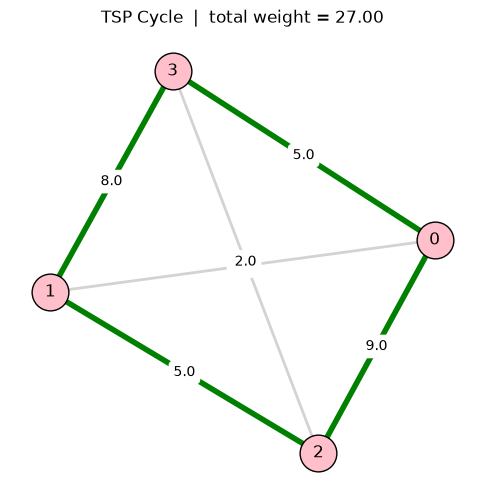

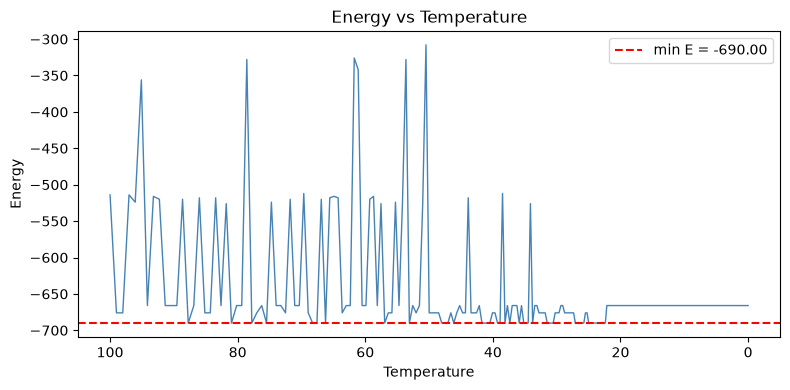

that gives us  sum of W=None


In [391]:
G = nx.complete_graph(4)
for u, v in G.edges():
    G[u][v]['weight'] = np.random.randint(1, 10)

W = nx.to_numpy_array(G, weight='weight')

C=10

B = 1
A = C * B * W.max()
print("A:", A)
Q = build_tsp(G, A, B)

# brute force 
best_E, best_x = brute_force_qubo(Q)
bf_cycle, bf_valid = read_tsp(G, best_x)
print(f"Brute force minimum energy: {best_E:.2f}")

#annealing
for i in range(3):
    print(f"run {i+1}\n")
    temps, energies, anneal_x , cycle, valid = tsp_anneal(G,A,B,
            T_start=100,
            T_end=0.001,
            alpha=0.99,
            sweeps_per_T=2000)
    read_tsp(G, anneal_x)
    plot_tsp(G, cycle, valid)
    sumW = plot_TvE(temps, energies)
    print(f"that gives us  sum of W={sumW}")
    


In [382]:
best_energy, best_x = brute_force_qubo(Q)

read_tsp(G, best_x)
#plot_tsp(G, cycle, valid)
print(f"best E ={best_energy}")

Vertex 1: invalid positions []
Position 0: invalid vertices []
best E =-44.0


This seems to work however we aren't finding the minimum weight sum everytime.

In [ ]:
results = []
for _ in range(20):
    _, _, x = sim_annealing_QUBO(Q, T_start=50.0, T_end=0.001,
                             alpha=0.99, sweeps_per_T=1000)
    x = x.round()
    cycle, valid = read_tsp(G, x)
    if valid:
        results.append(cycle[2])  # total weight

print(f"Valid solutions: {len(results)}/20")
print(f"Best weight: {min(results):.2f}")
print(f"Worst weight: {max(results):.2f}")

Vertex 1: invalid positions []
Position 0: invalid vertices []
Cycle: [None, 0, 3, 2]
Missing edges: []
Total weight: 0.00
Valid: False
Vertex 1: invalid positions []
Position 1: invalid vertices []
Cycle: [0, None, 2, 3]
Missing edges: []
Total weight: 0.00
Valid: False
Vertex 1: invalid positions []
Position 3: invalid vertices []
Cycle: [2, 3, 0, None]
Missing edges: []
Total weight: 0.00
Valid: False
Vertex 1: invalid positions []
Position 1: invalid vertices []
Cycle: [0, None, 2, 3]
Missing edges: []
Total weight: 0.00
Valid: False
Vertex 1: invalid positions []
Position 0: invalid vertices []
Cycle: [None, 0, 3, 2]
Missing edges: []
Total weight: 0.00
Valid: False
Vertex 1: invalid positions []
Position 2: invalid vertices []
Cycle: [3, 2, None, 0]
Missing edges: []
Total weight: 0.00
Valid: False


KeyboardInterrupt: 

In [390]:
G = nx.complete_graph(4)
for u, v in G.edges():
    G[u][v]['weight'] = np.random.randint(1, 10)

W = nx.to_numpy_array(G, weight='weight')

C=10

B = 1
A = C * B * W.max()
print("A:", A)

Q = build_tsp(G, A, B)


# check what the brute force solution actually is
best_E, best_x = brute_force_qubo(Q)
print(f"Brute force energy: {best_E:.2f}")
print(f"Brute force x: {best_x}")
bf_cycle, bf_valid = read_tsp(G, best_x, verbose=True)

# check annealer solution
_, _, anneal_x, cycle, valid = tsp_anneal(G,A,B,
            T_start=100,
            T_end=0.001,
            alpha=0.99,
            sweeps_per_T=2000)

read_tsp(G, anneal_x, verbose=True)

anneal_E = anneal_x @ Q @ anneal_x
print(f"Annealer energy: {anneal_E:.2f}")
print(f"Valid: {valid}")

A: 90.0
Brute force energy: -682.00
Brute force x: [0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0]
Cycle: [3, 2, 1, 0]
Missing edges: []
Total weight: 19.00
Valid: True
anneal
Cycle: [3, 0, 1, 2]
Missing edges: []
Total weight: 19.00
Valid: True
Annealer energy: -682.00
Valid: True
